# Decision Trees — Implementation and Application

This notebook covers two angles:
1. **From-scratch implementation** — Node, entropy, information gain, build_tree, predict, and custom visualization
2. **Scikit-Learn application** — real drug prediction dataset, EDA, full evaluation, and hyperparameter exploration

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

---
## Part 1 — From-Scratch Implementation

### How does a Decision Tree work?

A Decision Tree recursively splits the dataset by choosing, at each node, the feature and threshold that maximize **Information Gain**.

**Entropy** of a set with classes $c_1, c_2, ..., c_k$:

$$H(y) = -\sum_{i=1}^{k} p_i \log_2(p_i)$$

**Information Gain** when splitting parent into left/right children:

$$IG = H(\text{parent}) - \left(\frac{|L|}{|P|} H(L) + \frac{|R|}{|P|} H(R)\right)$$

The algorithm stops splitting when:
- The node has too few samples (`min_samples_split`)
- Maximum depth is reached (`max_depth`)
- Information gain is zero (pure node)

In [7]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, info_gain=None,
                 left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.info_gain = info_gain
        self.left = left
        self.right = right
        self.value = value  # only set on leaf nodes

In [8]:
class DecisionTree:
    def __init__(self, min_samples_split=2, max_depth=2):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.root = None

    # ── Entropy ─────────────────────────────────────────────────────
    def entropy(self, y):
        entropy = 0
        for label in np.unique(y):
            p = np.sum(y == label) / len(y)
            entropy -= p * np.log2(p)
        return entropy

    # ── Information Gain ────────────────────────────────────────────
    def information_gain(self, parent_y, left_y, right_y):
        w_left = len(left_y) / len(parent_y)
        w_right = len(right_y) / len(parent_y)
        return self.entropy(parent_y) - (w_left * self.entropy(left_y) + w_right * self.entropy(right_y))

    # ── Split into two subsets ───────────────────────────────────────
    def split(self, dataset, feature_idx, threshold):
        left = dataset[dataset[:, feature_idx] <= threshold]
        right = dataset[dataset[:, feature_idx] > threshold]
        return left, right

    # ── Find the best split ──────────────────────────────────────────
    def best_split(self, dataset, n_features):
        best = {'feature_idx': None, 'threshold': None,
                'info_gain': -1, 'left_dataset': None, 'right_dataset': None}

        for feat in range(n_features):
            for threshold in np.unique(dataset[:, feat]):
                left, right = self.split(dataset, feat, threshold)
                if len(left) == 0 or len(right) == 0:
                    continue
                ig = self.information_gain(dataset[:, -1], left[:, -1], right[:, -1])
                if ig > best['info_gain']:
                    best = {'feature_idx': feat, 'threshold': threshold,
                            'info_gain': ig, 'left_dataset': left, 'right_dataset': right}
        return best

    # ── Recursive tree building ──────────────────────────────────────
    def build_tree(self, dataset, depth=0):
        X, y = dataset[:, :-1], dataset[:, -1]
        n_samples, n_features = X.shape

        if n_samples >= self.min_samples_split and depth <= self.max_depth:
            best = self.best_split(dataset, n_features)
            if best['info_gain'] > 0:
                left_node = self.build_tree(best['left_dataset'], depth + 1)
                right_node = self.build_tree(best['right_dataset'], depth + 1)
                return Node(best['feature_idx'], best['threshold'],
                            best['info_gain'], left_node, right_node)

        # Leaf node: most common class
        leaf_value = Counter(y).most_common(1)[0][0]
        return Node(value=leaf_value)

    # ── Training ────────────────────────────────────────────────────
    def fit(self, X, y):
        dataset = np.concatenate([X, y.reshape(-1, 1)], axis=1)
        self.root = self.build_tree(dataset)

    # ── Prediction ──────────────────────────────────────────────────
    def _predict_single(self, row, node):
        if node.value is not None:
            return node.value
        if row[node.feature_idx] <= node.threshold:
            return self._predict_single(row, node.left)
        return self._predict_single(row, node.right)

    def predict(self, X):
        return np.array([self._predict_single(row, self.root) for row in X])

    # ── Tree visualization ──────────────────────────────────────────
    def print_tree(self, feature_names=None, class_names=None, figsize=None):
        node = self.root
        if node is None:
            raise ValueError("Train the model with fit() before calling print_tree().")

        def tree_depth(n):
            if n is None or n.value is not None:
                return 0
            return 1 + max(tree_depth(n.left), tree_depth(n.right))

        def count_leaves(n):
            if n is None:
                return 0
            if n.value is not None:
                return 1
            return count_leaves(n.left) + count_leaves(n.right)

        def node_text(n):
            if n.value is not None:
                label = class_names[int(n.value)] if class_names else n.value
                return f"Class: {label}"
            fname = feature_names[n.feature_idx] if feature_names else f"Feature {n.feature_idx}"
            return f"{fname}\n<= {n.threshold:.3f}\nIG = {n.info_gain:.3f}"

        max_depth = tree_depth(node)
        total_leaves = max(count_leaves(node), 1)
        if figsize is None:
            figsize = (max(8, total_leaves * 2.2), max(5, (max_depth + 1) * 1.6))

        fig, ax = plt.subplots(figsize=figsize)
        ax.axis("off")
        leaf_x_counter = [0]

        def draw(n, depth=0):
            y_pos = -depth
            if n.value is not None:
                x_pos = leaf_x_counter[0]
                leaf_x_counter[0] += 1
            else:
                lx, ly = draw(n.left, depth + 1)
                rx, ry = draw(n.right, depth + 1)
                x_pos = (lx + rx) / 2
                ax.annotate("yes", xy=(lx, ly), xytext=(x_pos, y_pos),
                            ha="center", va="center", fontsize=9,
                            arrowprops=dict(arrowstyle="->", lw=1.2, color="#555"))
                ax.annotate("no", xy=(rx, ry), xytext=(x_pos, y_pos),
                            ha="center", va="center", fontsize=9,
                            arrowprops=dict(arrowstyle="->", lw=1.2, color="#555"))

            color = "#d8f3dc" if n.value is not None else "#dbeafe"
            ax.text(x_pos, y_pos, node_text(n), ha="center", va="center", fontsize=10,
                    bbox=dict(boxstyle="round,pad=0.45", facecolor=color,
                              edgecolor="#334155", linewidth=1.2))
            return x_pos, y_pos

        draw(node)
        ax.set_xlim(-0.8, max(total_leaves - 0.2, 1))
        ax.set_ylim(-(max_depth + 0.8), 0.8)
        plt.tight_layout()
        plt.show()

### 1.1 Testing on the Iris Dataset

In [9]:
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(
    X_iris, y_iris, test_size=0.2, random_state=123
)

dt_scratch = DecisionTree(min_samples_split=2, max_depth=3)
dt_scratch.fit(X_train_iris, y_train_iris)

preds_iris = dt_scratch.predict(X_test_iris)
acc = np.mean(preds_iris == y_test_iris) * 100
print(f"Accuracy (from scratch, Iris): {acc:.2f}%")

Accuracy (from scratch, Iris): 96.67%


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

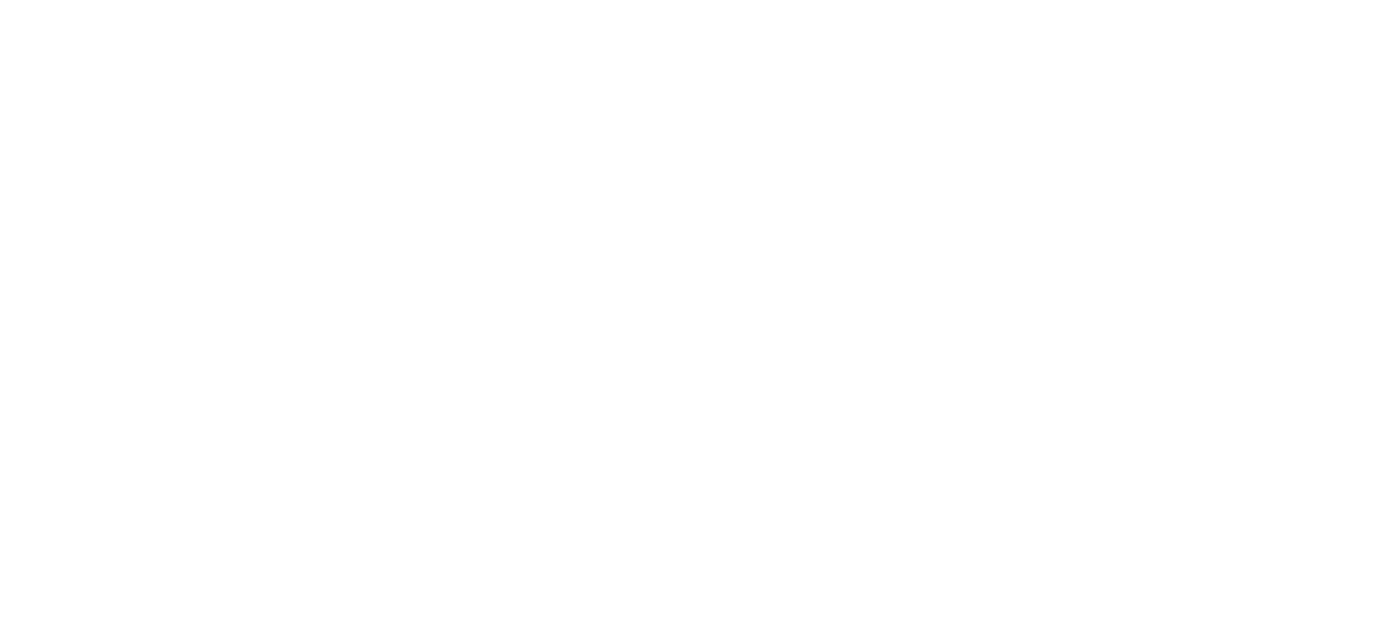

In [10]:
dt_scratch.print_tree(
    feature_names=iris.feature_names,
    class_names=iris.target_names
)

---
## Part 2 — Scikit-Learn Application: Drug Prediction

### Context
Dataset of 200 patients who suffered from the same illness. Each patient responded to one of 5 medications (Drug A, B, C, X, or Y). The goal is to build a model that recommends the correct drug based on patient features:
- **Age**
- **Sex**
- **BP** — blood pressure (High, Normal, Low)
- **Cholesterol** (High, Normal)
- **Na_to_K** — sodium-to-potassium ratio in blood

### 2.1 Loading the Data

In [11]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv'
df = pd.read_csv(url)
df.head(10)

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY
5,22,F,NORMAL,HIGH,8.607,drugX
6,49,F,NORMAL,HIGH,16.275,drugY
7,41,M,LOW,HIGH,11.037,drugC
8,60,M,NORMAL,HIGH,15.171,drugY
9,43,M,LOW,NORMAL,19.368,drugY


In [12]:
print(df.shape)
df.info()

(200, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [13]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

### 2.2 Exploratory Data Analysis (EDA)

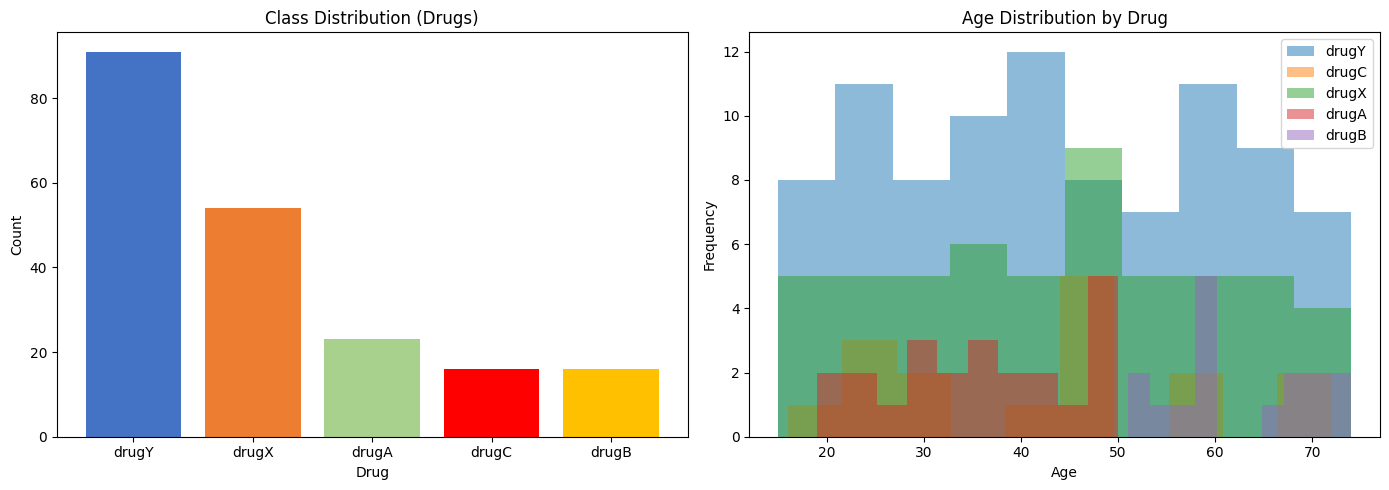

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['Drug'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4472C4','#ED7D31','#A9D18E','#FF0000','#FFC000'])
axes[0].set_title('Class Distribution (Drugs)')
axes[0].set_xlabel('Drug')
axes[0].set_ylabel('Count')

for drug in df['Drug'].unique():
    axes[1].hist(df[df['Drug'] == drug]['Age'], alpha=0.5, label=drug, bins=10)
axes[1].set_title('Age Distribution by Drug')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

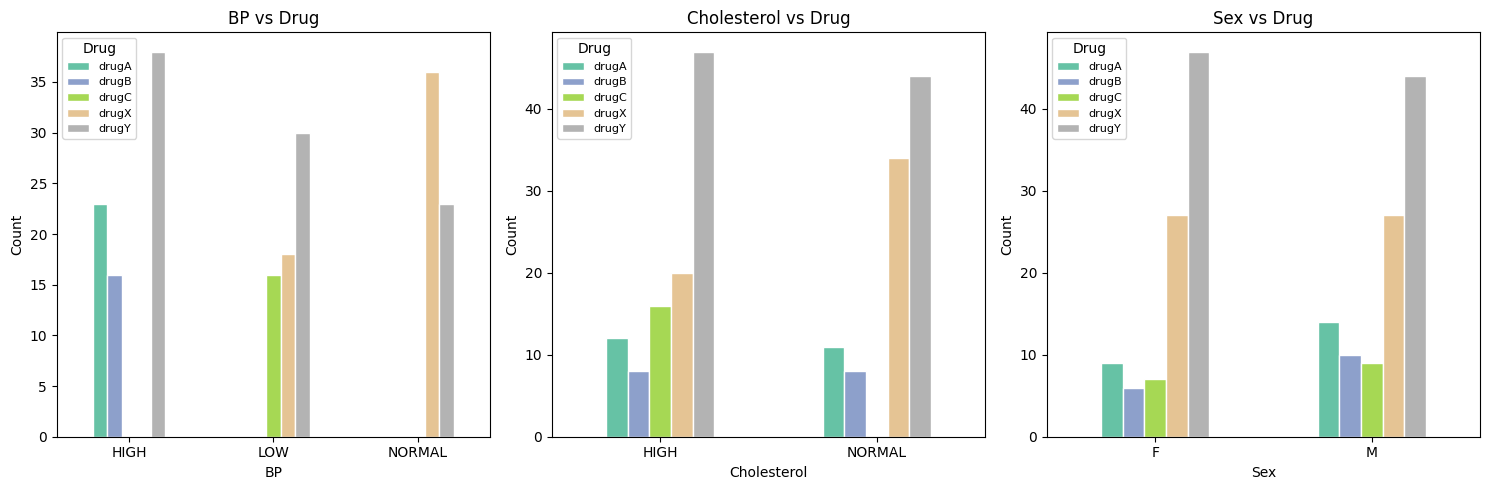

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, ['BP', 'Cholesterol', 'Sex']):
    crosstab = pd.crosstab(df[col], df['Drug'])
    crosstab.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
    ax.set_title(f'{col} vs Drug')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title='Drug', fontsize=8)

plt.tight_layout()
plt.show()

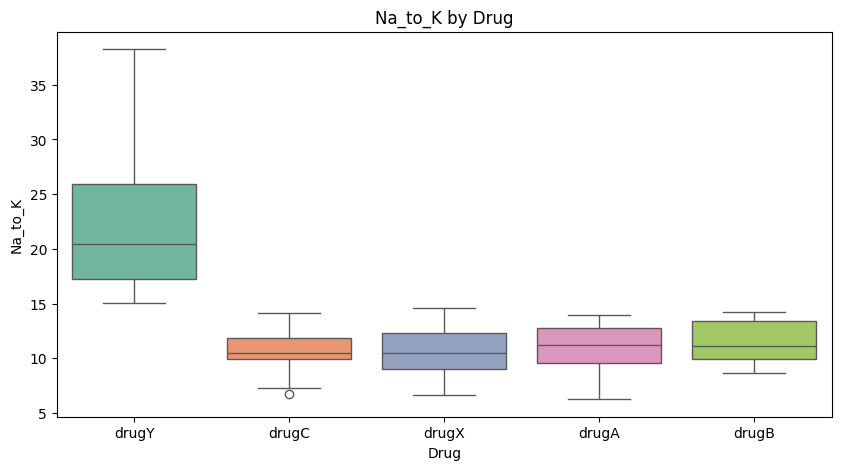

In [18]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Drug', y='Na_to_K', data=df, palette='Set2')
plt.title('Na_to_K by Drug')
plt.xlabel('Drug')
plt.ylabel('Na_to_K')
plt.show()

### 2.3 Preprocessing

In [19]:
df_model = df.copy()

le = LabelEncoder()
for col in ['Sex', 'BP', 'Cholesterol']:
    df_model[col] = le.fit_transform(df_model[col])

print("Label encoding mappings:")
print("Sex: M→1, F→0")
print("BP: High→0, Low→1, Normal→2")
print("Cholesterol: High→0, Normal→1")
df_model.head()

Label encoding mappings:
Sex: M→1, F→0
BP: High→0, Low→1, Normal→2
Cholesterol: High→0, Normal→1


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,drugY
1,47,1,1,0,13.093,drugC
2,47,1,1,0,10.114,drugC
3,28,0,2,0,7.798,drugX
4,61,0,1,0,18.043,drugY


In [20]:
# Correlation with the target variable
drug_map = {'drugA': 0, 'drugB': 1, 'drugC': 2, 'drugX': 3, 'drugY': 4}
df_model['Drug_num'] = df_model['Drug'].map(drug_map)

corr = df_model.drop('Drug', axis=1).corr()['Drug_num'].drop('Drug_num').sort_values(key=abs, ascending=False)
print("Correlation with target variable:")
print(corr)

Correlation with target variable:
Na_to_K        0.589120
BP             0.372868
Sex           -0.098573
Cholesterol    0.055629
Age           -0.004828
Name: Drug_num, dtype: float64


### 2.4 Training and Evaluation

In [21]:
X = df_model.drop(['Drug', 'Drug_num'], axis=1)
y = df_model['Drug']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=32)
print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 140 samples | Test: 60 samples


In [22]:
drug_tree = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=32)
drug_tree.fit(X_train, y_train)

y_pred = drug_tree.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")

Accuracy: 98.33%


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       drugA       1.00      1.00      1.00         8
       drugB       1.00      1.00      1.00         5
       drugC       1.00      1.00      1.00         3
       drugX       1.00      0.94      0.97        16
       drugY       0.97      1.00      0.98        28

    accuracy                           0.98        60
   macro avg       0.99      0.99      0.99        60
weighted avg       0.98      0.98      0.98        60



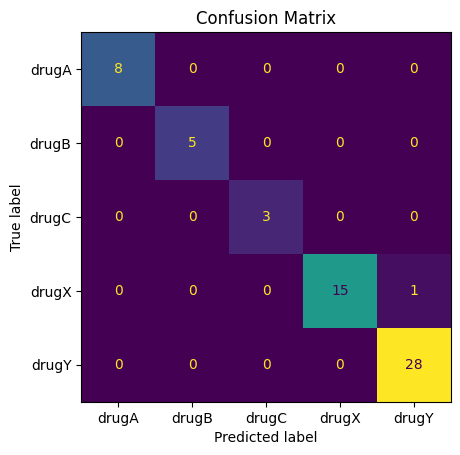

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False)
plt.title('Confusion Matrix')
plt.show()

### 2.5 Visualizing the Tree

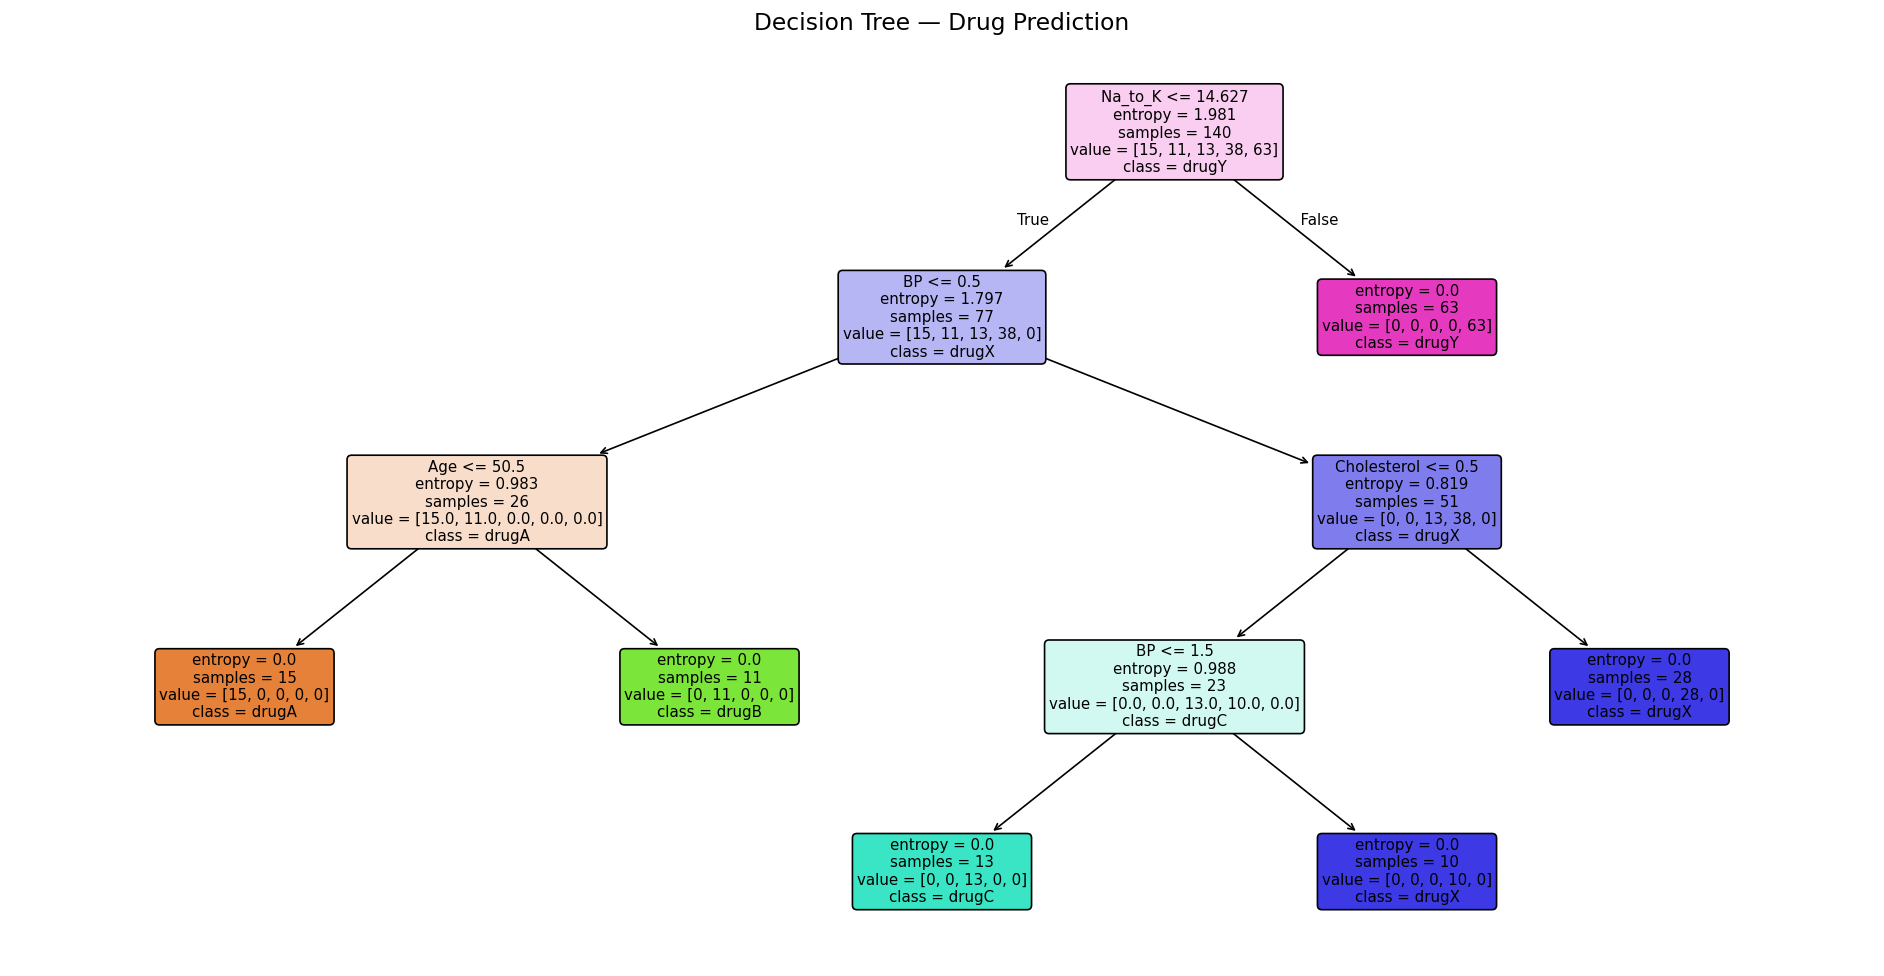

In [25]:
plt.figure(figsize=(20, 10), dpi=120)
plot_tree(
    drug_tree,
    filled=True,
    feature_names=X.columns,
    class_names=drug_tree.classes_,
    rounded=True,
    impurity=True,
    fontsize=9
)
plt.title('Decision Tree — Drug Prediction', fontsize=14)
plt.show()

### 2.6 Feature Importance

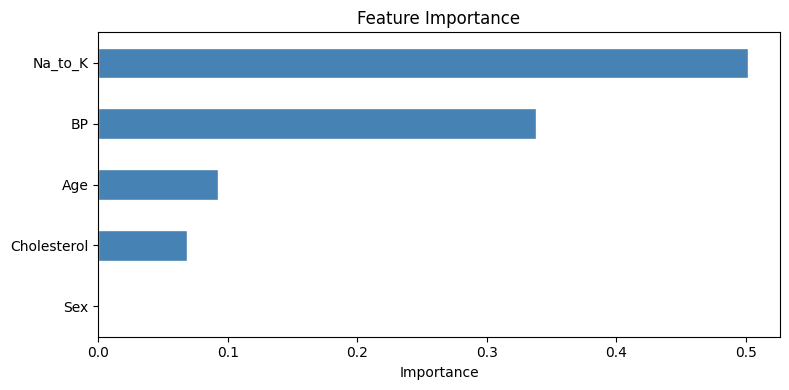

In [26]:
importances = pd.Series(drug_tree.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(8, 4))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

### 2.7 Effect of `max_depth` Hyperparameter

Comparing train vs. test accuracy across different values of max depth.

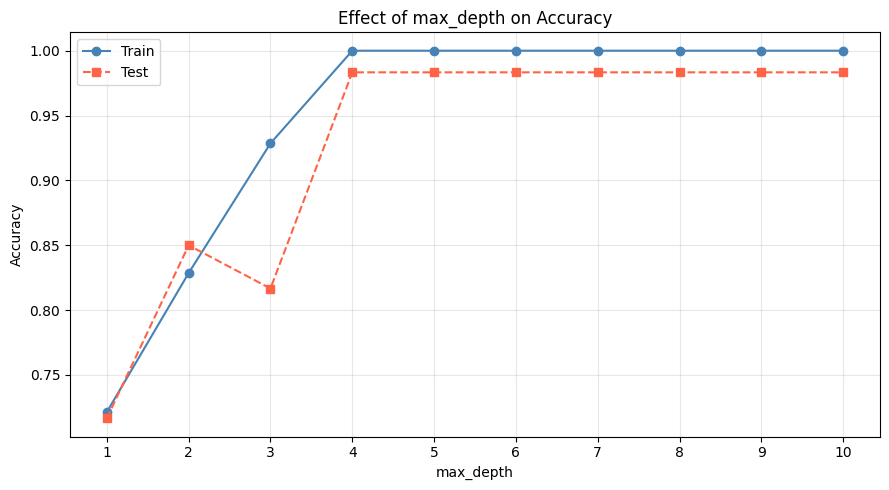

Best max_depth on test set: 4 → accuracy 0.9833


In [27]:
depths = range(1, 11)
train_accs = []
test_accs = []

for d in depths:
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=32)
    clf.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, clf.predict(X_train)))
    test_accs.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_accs, 'o-', label='Train', color='steelblue')
plt.plot(depths, test_accs, 's--', label='Test', color='tomato')
plt.xticks(depths)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Effect of max_depth on Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = list(depths)[np.argmax(test_accs)]
print(f"Best max_depth on test set: {best_depth} → accuracy {max(test_accs):.4f}")

### 2.8 Impurity Criterion: Entropy vs Gini

In [28]:
for criterion in ['entropy', 'gini']:
    clf = DecisionTreeClassifier(criterion=criterion, max_depth=4, random_state=32)
    clf.fit(X_train, y_train)
    acc = accuracy_score(y_test, clf.predict(X_test))
    print(f"criterion='{criterion}' → test accuracy: {acc * 100:.2f}%")

criterion='entropy' → test accuracy: 98.33%
criterion='gini' → test accuracy: 98.33%


---
## Summary

| | Iris (from scratch) | Drugs (Scikit-Learn) |
|---|---|---|
| **Features** | 4 numerical | 5 mixed (+ encoding) |
| **Classes** | 3 species | 5 drugs |
| **Criterion** | Entropy (IG) | Entropy / Gini |
| **Accuracy** | ~96% | ~98% |

**Key takeaways:**
- `Na_to_K > 14.6` alone is enough to classify DrugY (root node of the tree)
- `max_depth` controls the bias/variance trade-off — overly deep trees overfit
- `criterion='entropy'` and `criterion='gini'` typically yield very similar results